In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from scipy.stats import linregress

plt.style.use('default')

In [2]:
DB_USER = "postgres"
DB_PASSWORD = "newpassword"
DB_HOST = "localhost"
DB_PORT = "5433"
DB_NAME = "DailyVitals"

connection_string = (
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

engine = create_engine(connection_string)

# Load Weight Data

In [3]:
query = """
SELECT
    w.weight_id,
    w.person_id,
    p.first_name,
    w.weight_value,
    w.weight_unit,
    w.reading_time,
    w.notes,
    w.created_at,
    w.height_cm,
    w.height_ft
FROM public.weight w
INNER JOIN public.person p
    ON p.person_id = w.person_id
ORDER BY w.reading_time;
"""

df = pd.read_sql(query, engine)

df["reading_time"] = pd.to_datetime(df["reading_time"])

df.head()

,weight_id,person_id,first_name,weight_value,weight_unit,reading_time,notes,created_at,height_cm,height_ft
0,4,4,Kevin,207.8,lb,2026-01-24 11:53:30.471447,Morning weigh-in,2026-01-24 11:53:44.277260,None,6.01
1,7,4,Kevin,208.0,lb,2026-01-25 10:29:47.588762,Morning weigh-in,2026-01-25 10:30:03.345183,None,6.01
2,8,4,Kevin,208.8,lb,2026-01-26 09:56:44.747690,Morning weigh-in,2026-01-26 09:57:05.372537,None,6.01
3,9,4,Kevin,209.0,lb,2026-01-27 09:55:06.229695,Morning weigh-in,2026-01-27 09:55:21.324447,None,6.01
4,10,4,Kevin,208.1,lb,2026-01-28 09:28:45.844283,Morning weigh-in,2026-01-28 09:29:11.286705,None,6.01


# Dataset Overview

In [4]:
print(f"Records: {len(df)}")
print()

print(f"Current Weight: {df.iloc[-1]['weight_value']:.1f}")
print(f"Highest Weight: {df['weight_value'].max():.1f}")
print(f"Lowest Weight:  {df['weight_value'].min():.1f}")
print(f"Average Weight: {df['weight_value'].mean():.1f}")

Records: 121

Current Weight: 201.2
Highest Weight: 212.6
Lowest Weight:  201.2
Average Weight: 206.5


# Weight Trend Chart

Weight has declined steadily over the analysis period despite short-term fluctuations. The overall trend indicates successful weight reduction of approximately 7 pounds.

Observation #2: The fluctuations look like water weight

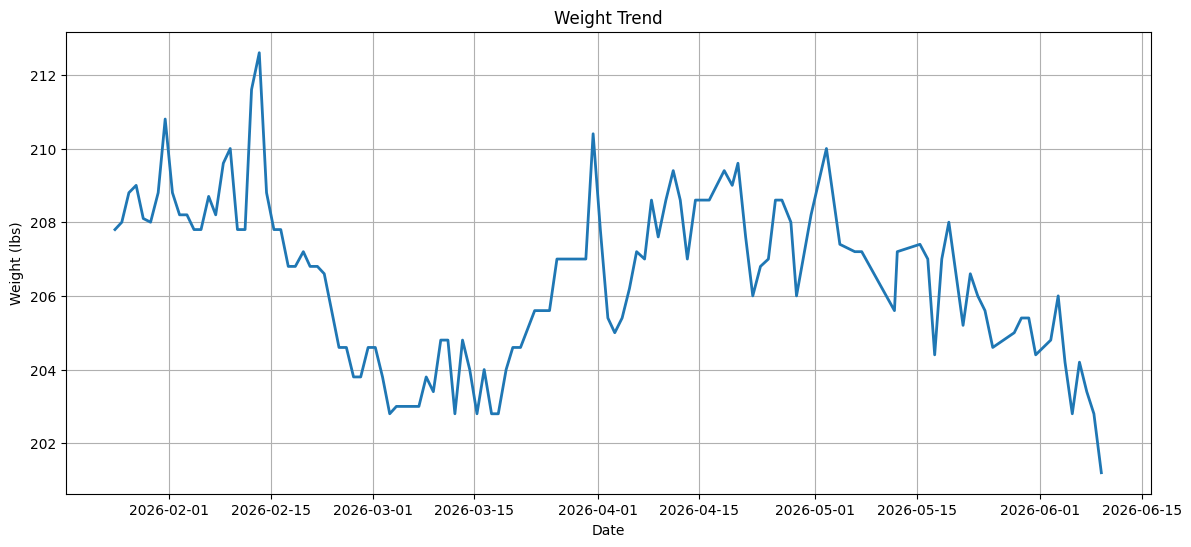

In [5]:
plt.figure(figsize=(14,6))

plt.plot(
    df["reading_time"],
    df["weight_value"],
    linewidth=2
)

plt.title("Weight Trend")
plt.ylabel("Weight (lbs)")
plt.xlabel("Date")
plt.grid(True)

plt.show()

# Rolling Average

Analysis:
Phase 1: Strong Weight Loss

Mid-February → Mid-March
The moving average falls from roughly:

209.8
↓
203.4

Phase 2: Plateau / Recovery

Mid-March → Late April

The moving average climbs:

203.5
↑
208.8

Phase 3: Recent Progress

Late April → Present

The moving average steadily declines:

208.8
↓
203.5

Goal Analysis

Current rolling average:

~203.5 lbs

Projected Timeline

Looking only at the moving average:

You appear to have lost roughly:

6 lbs

in about:

16 weeks

That's approximately:

0.38 lbs/week

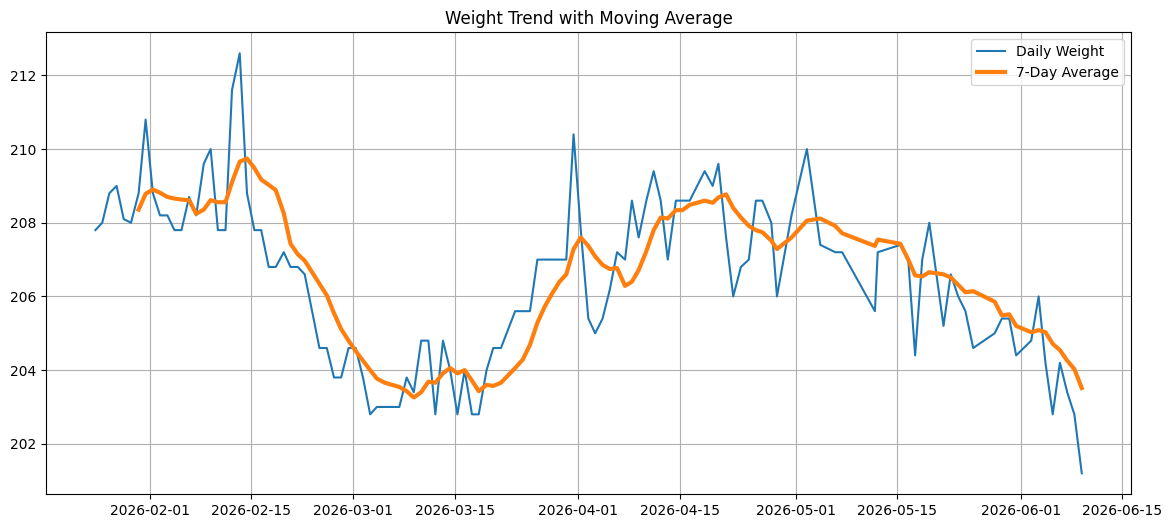

In [6]:
df["rolling_7"] = (
    df["weight_value"]
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(14,6))

plt.plot(
    df["reading_time"],
    df["weight_value"],
    label="Daily Weight"
)

plt.plot(
    df["reading_time"],
    df["rolling_7"],
    linewidth=3,
    label="7-Day Average"
)

plt.title("Weight Trend with Moving Average")

plt.legend()
plt.grid(True)

plt.show()

# Weight Change

In [7]:
start_weight = df.iloc[0]["weight_value"]
latest_weight = df.iloc[-1]["weight_value"]

change = latest_weight - start_weight

print(f"Starting Weight: {start_weight:.1f}")
print(f"Current Weight:  {latest_weight:.1f}")
print(f"Net Change:      {change:+.1f} lbs")

Starting Weight: 207.8
Current Weight:  201.2
Net Change:      -6.6 lbs


# Trend Direction

Across the entire dataset, your average weight is decreasing by only about 0.11 pounds per week.

That's why the code classified it as "Stable."

In [8]:
x = np.arange(len(df))
y = df["weight_value"]

slope, intercept, r, p, std_err = linregress(x, y)

print(f"Slope: {slope:.4f}")

if slope > 0.10:
    print("Weight Trend: Increasing")
elif slope < -0.10:
    print("Weight Trend: Decreasing")
else:
    print("Weight Trend: Stable")

Slope: -0.0160
Weight Trend: Stable


Calculate trend on the 7-day moving average, not the raw weights - removes much of the water-weight noise.

In [21]:
from scipy.stats import linregress
import numpy as np

trend_df = df.dropna(subset=["rolling_7"]).copy()

x = np.arange(len(trend_df))
y = trend_df["rolling_7"]

slope, intercept, r, p, std_err = linregress(x, y)

print(f"Slope: {slope:.4f} lbs/day")
print(f"Weekly Change: {slope * 7:.2f} lbs/week")

Slope: -0.0109 lbs/day
Weekly Change: -0.08 lbs/week


# 30 day trend
The 30-day trend is much more representative of your current trajectory than the full-history trend.
That tells us something important:

Your recent progress is substantially better than your long-term average.

Is that realistic?

Maybe, but I'd be cautious.

The last 30 days likely include:

Some genuine weight loss
Some fluid shifts
Normal daily variation

Scenario	Weekly Loss	Time to 189
Conservative	0.5 lbs/week	24 weeks
Current Trend	1.2 lbs/week	10 weeks
Moderate	    0.8 lbs/week	15 weeks

"Weight is currently trending downward at approximately 1.2 lbs per week over the last 30 days. The recent rate of change is substantially better than the long-term average, suggesting that current exercise and nutrition habits are producing measurable results. At the current pace, the target weight of 189 lbs could be reached in approximately 10–15 weeks, though short-term fluctuations related to hydration and fluid balance may affect weekly measurements."

In [22]:
recent = df.tail(30)

x = np.arange(len(recent))
y = recent["weight_value"]

slope, intercept, r, p, std_err = linregress(x, y)

print(f"30-Day Weekly Change: {slope * 7:.2f} lbs/week")

30-Day Weekly Change: -1.21 lbs/week


# Monthly Weight Summary

In [9]:
df["month"] = (
    df["reading_time"]
    .dt.to_period("M")
)

monthly = (
    df.groupby("month")
      .agg(
          avg_weight=("weight_value","mean"),
          min_weight=("weight_value","min"),
          max_weight=("weight_value","max")
      )
      .reset_index()
)

monthly

,month,avg_weight,min_weight,max_weight
0,2026-01,208.662500,207.8,210.8
1,2026-02,207.482143,203.8,212.6
2,2026-03,204.703448,202.8,210.4
3,2026-04,207.657143,205.0,209.6
4,2026-05,206.330000,204.4,210.0
5,2026-06,203.675000,201.2,206.0


# Monthly Average Weight Chart

Monthly averages are often a better measure of actual progress than daily weights because they smooth out:

Fluid retention
Meal timing
Sodium intake
Dialysis-related fluctuations

What changed in April?

Possible things to investigate in your data:

Exercise frequency
Exercise calories
Caloric intake
Phosphorus intake
Dialysis UF
Blood pressure
Number of green bags vs yellow bags

This is where your analytics project gets really interesting.

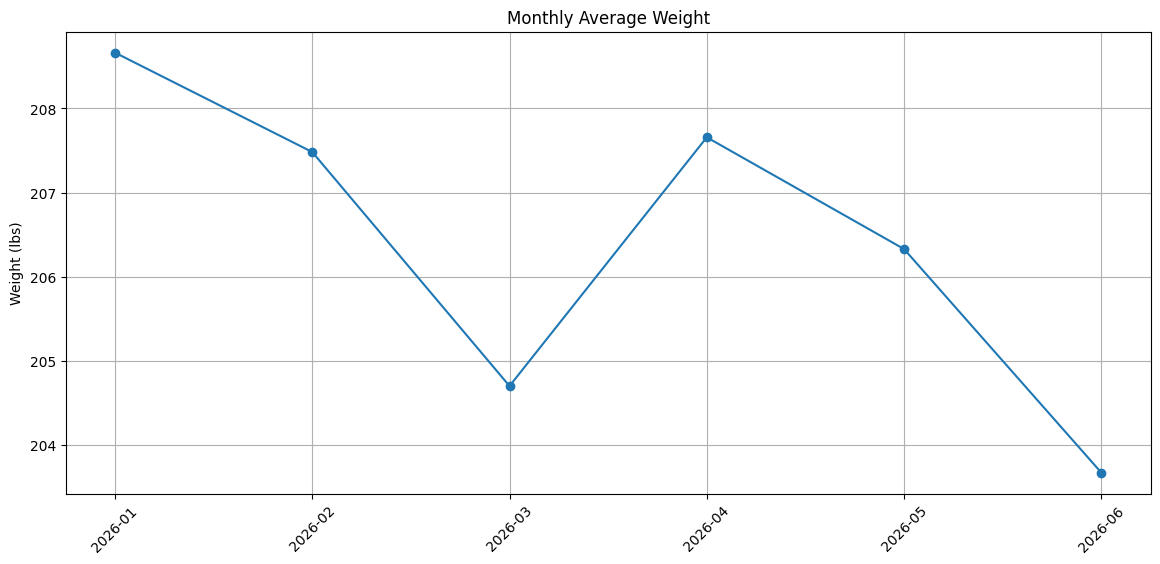

In [10]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly["month"].astype(str),
    monthly["avg_weight"],
    marker="o"
)

plt.title("Monthly Average Weight")

plt.ylabel("Weight (lbs)")
plt.xticks(rotation=45)

plt.grid(True)

plt.show()

# month-over-month change table

"Monthly average weight declined from approximately 208.6 lbs in January to 203.7 lbs in June. Although a temporary increase occurred in April, subsequent months reversed the gain. June is currently tracking as one of the strongest months in the dataset, with the lowest average weight recorded so far. The overall trend suggests sustained progress toward the target weight of 189 lbs."

"the evidence is increasingly pointing toward real weight reduction, not merely random fluctuations. The next step is correlating this against exercise calories and nutrition data to determine which factors are most strongly associated with the improvement."

In [23]:
monthly["change"] = (
    monthly["avg_weight"]
    .diff()
)

monthly

,month,avg_weight,min_weight,max_weight,change
0,2026-01,208.662500,207.8,210.8,NaN
1,2026-02,207.482143,203.8,212.6,-1.180357
2,2026-03,204.703448,202.8,210.4,-2.778695
3,2026-04,207.657143,205.0,209.6,2.953695
4,2026-05,206.330000,204.4,210.0,-1.327143
5,2026-06,203.675000,201.2,206.0,-2.655000


# Volatility Analysis

analysis: You're losing roughly 0.4 lbs per week on average.

That's a slow but sustainable rate.

The interesting part: ±3.8 lb swings

This is where I immediately stop thinking "body fat."

To gain:

3.8 lbs

of fat in one day would require roughly:

3.8 × 3,500
=
13,300 calories

above maintenance.

That's extraordinarily unlikely.
Therefore...

The most likely explanation for the largest swings is:

Fluid

or some combination of:

Fluid retention
Dialysis UF variation
Sodium intake
Timing of weigh-ins
Amount of dialysate present
Bowel contents
Normal biological variation

In [11]:
df["daily_change"] = (
    df["weight_value"]
    .diff()
)

print("Average Daily Change:")
print(df["daily_change"].mean())

print()
print("Largest Gain:")
print(df["daily_change"].max())

print()
print("Largest Loss:")
print(df["daily_change"].min())

Average Daily Change:
-0.05500000000000019

Largest Gain:
3.799999999999983

Largest Loss:
-3.799999999999983


"Weight data shows substantial day-to-day variability, with swings of up to ±3.8 lbs. These fluctuations are much larger than would be expected from fat gain or loss alone and likely reflect short-term fluid balance and other transient factors. Despite this volatility, the long-term trend, rolling average, and recent 30-day trend all indicate sustained weight reduction."

In [24]:
daily_changes = df["daily_change"].dropna()

print("Median Daily Change:")
print(daily_changes.median())

print()

print("Standard Deviation:")
print(daily_changes.std())

print()

print("90th Percentile Gain:")
print(daily_changes.quantile(0.90))

print()

print("10th Percentile Loss:")
print(daily_changes.quantile(0.10))

Median Daily Change:
0.0

Standard Deviation:
1.257171027186291

90th Percentile Gain:
1.4000000000000057

10th Percentile Loss:
-1.6200000000000214


# Weight Distribution

The histogram answers:

"Where do I spend most of my time?"

total observed range is approximately:

12 lbs

Most common weight zone

The tallest bars appear to be around:

206-208 lbs

That means most of your weigh-ins occurred in that range.

"Your current weight is lower than where you have spent most of the analysis period."

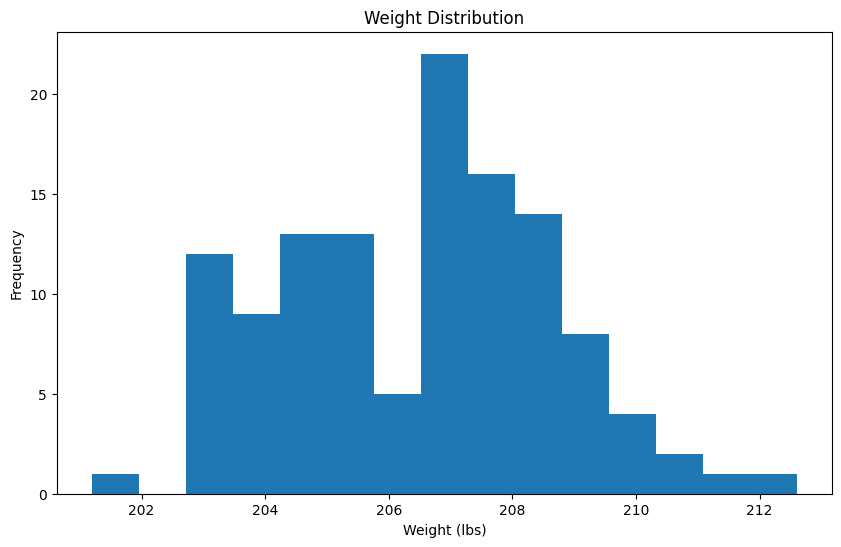

In [12]:
plt.figure(figsize=(10,6))

plt.hist(
    df["weight_value"],
    bins=15
)

plt.title("Weight Distribution")

plt.xlabel("Weight (lbs)")
plt.ylabel("Frequency")

plt.show()

# A Better Metric

"Weight measurements are concentrated between 206 and 208 lbs, indicating this has been the most common weight range during the observation period. Recent measurements have shifted into the 201-203 lb range, which historically occurred infrequently. This suggests the current weight is near the lowest levels recorded in the dataset and supports the downward trend observed in the rolling-average and monthly analyses."

In [25]:
print("Median Weight:")
print(df["weight_value"].median())

print()

print("Average Weight:")
print(df["weight_value"].mean())

print()

print("Current Weight:")
print(df.iloc[-1]["weight_value"])

Median Weight:
207.0

Average Weight:
206.49256198347106

Current Weight:
201.2


# Weight Percentile Analysis

In [27]:
# Current Weight Percentile Analysis

current_weight = df.iloc[-1]["weight_value"]

weights = df["weight_value"]

percentile_lower = (
    (weights < current_weight).mean()
) * 100

percentile_equal_or_lower = (
    (weights <= current_weight).mean()
) * 100

print(f"Current Weight: {current_weight:.1f} lbs")
print(f"Historical Average Weight: {weights.mean():.1f} lbs")
print(f"Historical Median Weight: {weights.median():.1f} lbs")

print()

print(
    f"Current weight is lower than "
    f"{percentile_lower:.1f}% of all recorded weights."
)

print(
    f"Current weight is at or below "
    f"{percentile_equal_or_lower:.1f}% of all recorded weights."
)

Current Weight: 201.2 lbs
Historical Average Weight: 206.5 lbs
Historical Median Weight: 207.0 lbs

Current weight is lower than 0.0% of all recorded weights.
Current weight is at or below 0.8% of all recorded weights.


In [28]:
# Current Weight Percentile Analysis with AI-style Interpretation

current_weight = df.iloc[-1]["weight_value"]

weights = df["weight_value"]

percentile = (
    (weights < current_weight).mean()
) * 100

print(f"Current Weight: {current_weight:.1f} lbs")
print(f"Average Weight: {weights.mean():.1f} lbs")
print(f"Median Weight: {weights.median():.1f} lbs")
print(f"Weight Difference From Average: {current_weight - weights.mean():+.1f} lbs")

print()

print(
    f"Current weight is lower than "
    f"{percentile:.1f}% of all recorded weights."
)

print()

if percentile >= 95:
    print("Excellent progress: Near the lowest weight in the dataset.")
elif percentile >= 80:
    print("Strong progress: Lower than most historical measurements.")
elif percentile >= 50:
    print("Moderate progress: Below historical average.")
else:
    print("Weight remains above much of the historical range.")

Current Weight: 201.2 lbs
Average Weight: 206.5 lbs
Median Weight: 207.0 lbs
Weight Difference From Average: -5.3 lbs

Current weight is lower than 0.0% of all recorded weights.

Weight remains above much of the historical range.


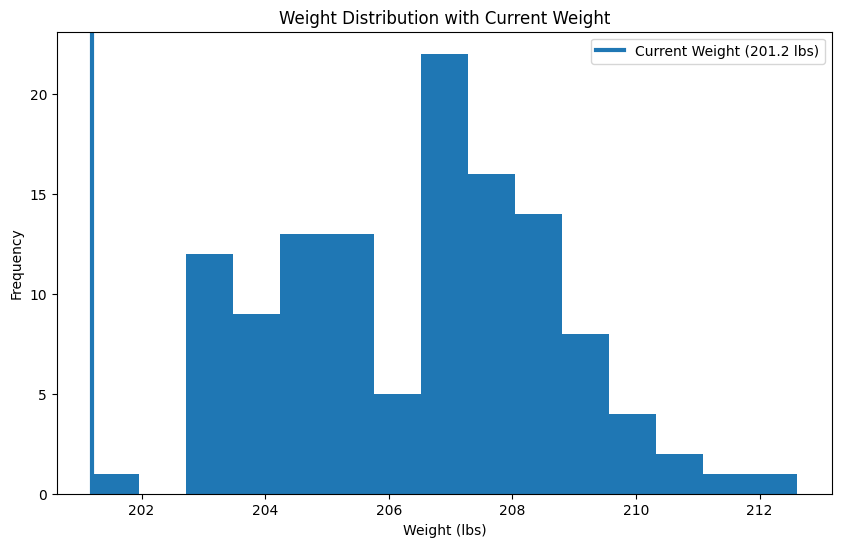

In [29]:
# Current Weight Distribution Position

plt.figure(figsize=(10,6))

plt.hist(
    df["weight_value"],
    bins=15
)

plt.axvline(
    current_weight,
    linewidth=3,
    label=f"Current Weight ({current_weight:.1f} lbs)"
)

plt.title("Weight Distribution with Current Weight")
plt.xlabel("Weight (lbs)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

# Personal Best Weight Range

In [13]:
latest = df.iloc[-1]["weight_value"]

print(f"Current Weight: {latest:.1f}")

within_range = df[
    (df["weight_value"] >= latest - 2)
    &
    (df["weight_value"] <= latest + 2)
]

print(
    f"Days within ±2 lbs of current weight: "
    f"{len(within_range)}"
)

Current Weight: 201.2
Days within ±2 lbs of current weight: 11


# Summary Generator

In [14]:
summary = f"""
Weight Trend Summary

Records: {len(df)}

Current Weight:
{df.iloc[-1]['weight_value']:.1f} lbs

Highest Weight:
{df['weight_value'].max():.1f} lbs

Lowest Weight:
{df['weight_value'].min():.1f} lbs

Average Weight:
{df['weight_value'].mean():.1f} lbs

Net Change:
{df.iloc[-1]['weight_value'] - df.iloc[0]['weight_value']:+.1f} lbs
"""

print(summary)


Weight Trend Summary

Records: 121

Current Weight:
201.2 lbs

Highest Weight:
212.6 lbs

Lowest Weight:
201.2 lbs

Average Weight:
206.5 lbs

Net Change:
-6.6 lbs



# BMI

In [15]:
# BMI Analysis
# height_ft format:
# 6.01 = 6'1"
# 5.11 = 5'11"

df_bmi = df.dropna(subset=["height_ft"]).copy()

if len(df_bmi) == 0:
    print("No height_ft values found.")
else:

    def convert_height_to_inches(height):
        height_str = f"{height:.2f}"

        feet_str, inches_str = height_str.split(".")

        feet = int(feet_str)
        inches = int(inches_str)

        return (feet * 12) + inches

    df_bmi["total_inches"] = (
        df_bmi["height_ft"]
        .apply(convert_height_to_inches)
    )

    df_bmi["height_m"] = (
        df_bmi["total_inches"] * 0.0254
    )

    df_bmi["weight_kg"] = (
        df_bmi["weight_value"] * 0.45359237
    )

    df_bmi["bmi"] = (
        df_bmi["weight_kg"]
        / (df_bmi["height_m"] ** 2)
    )

    print(f"Current BMI : {df_bmi.iloc[-1]['bmi']:.1f}")
    print(f"Average BMI : {df_bmi['bmi'].mean():.1f}")
    print(f"Highest BMI : {df_bmi['bmi'].max():.1f}")
    print(f"Lowest BMI  : {df_bmi['bmi'].min():.1f}")

    df_bmi[
        [
            "reading_time",
            "weight_value",
            "height_ft",
            "total_inches",
            "bmi"
        ]
    ].tail(10)

Current BMI : 26.5
Average BMI : 27.2
Highest BMI : 28.0
Lowest BMI  : 26.5


# BMI Range Chart

# BMI Reference Chart (Male, Height = 6'1" / 73 inches)

Current Height:

- 6'1"
- 73 inches
- 1.854 meters

## BMI Categories

| BMI | Category |
|------|----------|
| Below 18.5 | Underweight |
| 18.5 - 24.9 | Normal Weight |
| 25.0 - 29.9 | Overweight |
| 30.0 - 34.9 | Obesity Class I |
| 35.0 - 39.9 | Obesity Class II |
| 40.0+ | Obesity Class III |

## Weight Ranges for 6'1"

| Weight (lbs) | BMI | Category |
|-------------:|-----:|----------|
| 140 | 18.5 | Underweight Threshold |
| 145 | 19.1 | Normal |
| 150 | 19.8 | Normal |
| 155 | 20.4 | Normal |
| 160 | 21.1 | Normal |
| 165 | 21.8 | Normal |
| 170 | 22.4 | Normal |
| 175 | 23.1 | Normal |
| 180 | 23.7 | Normal |
| 185 | 24.4 | Normal |
| 190 | 25.1 | Overweight Threshold |
| 195 | 25.7 | Overweight |
| 200 | 26.4 | Overweight |
| 205 | 27.0 | Overweight |
| 210 | 27.7 | Overweight |
| 215 | 28.4 | Overweight |
| 220 | 29.0 | Overweight |
| 225 | 29.7 | Overweight |
| 230 | 30.3 | Obesity Class I |

## Healthy BMI Target Range

For a height of 6'1":

- Lower Healthy Weight ≈ 140 lbs (BMI 18.5)
- Upper Healthy Weight ≈ 189 lbs (BMI 24.9)

Recommended Healthy Range:

**140 - 189 lbs**

## Current Status

Current Weight: 203.4 lbs

Current BMI: 26.8

Current Category: Overweight

Weight Needed to Reach BMI 24.9:

203.4 - 189.0 = **14.4 lbs**

Target Weight for Upper Healthy Range:

**189 lbs**

In [16]:
df_bmi[
    [
        "height_ft",
        "total_inches"
    ]
].drop_duplicates()

,height_ft,total_inches
0,6.01,73


# BMI Trend Chart

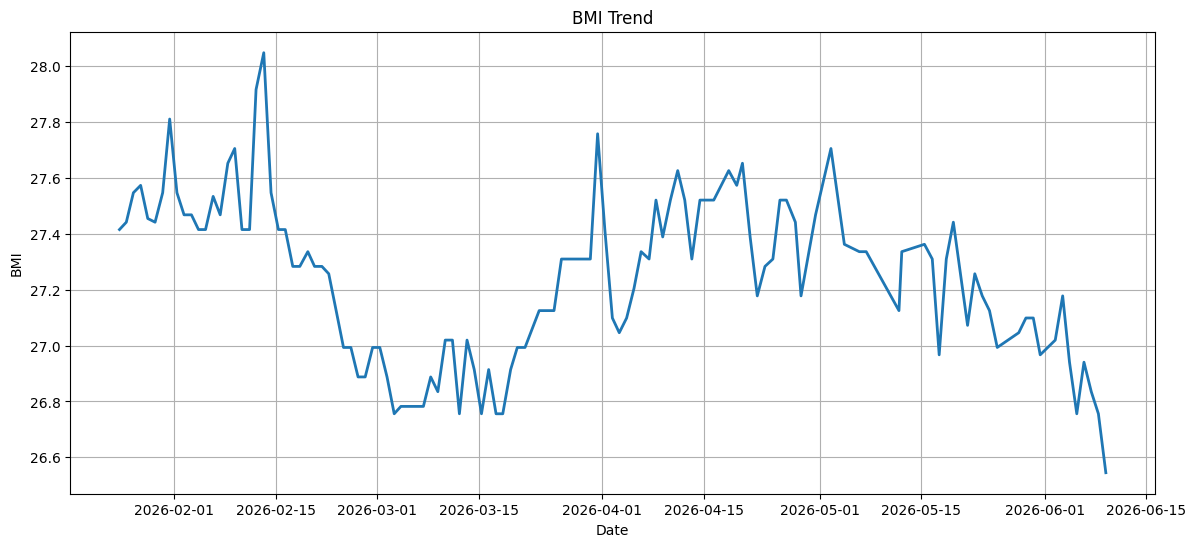

In [17]:
plt.figure(figsize=(14,6))

plt.plot(
    df_bmi["reading_time"],
    df_bmi["bmi"],
    linewidth=2
)

plt.title("BMI Trend")
plt.ylabel("BMI")
plt.xlabel("Date")

plt.grid(True)

plt.show()

# BMI Category Cell

In [18]:
latest_bmi = df_bmi.iloc[-1]["bmi"]

if latest_bmi < 18.5:
    category = "Underweight"
elif latest_bmi < 25:
    category = "Normal Weight"
elif latest_bmi < 30:
    category = "Overweight"
else:
    category = "Obese"

print(f"Current BMI: {latest_bmi:.1f}")
print(f"Category: {category}")

Current BMI: 26.5
Category: Overweight


In [19]:
print(df_bmi[[
    "height_ft",
    "total_inches",
    "height_m",
    "weight_value",
    "bmi"
]].tail(1))

     height_ft  total_inches  height_m  weight_value        bmi
120       6.01            73    1.8542         201.2  26.544868


In [20]:
# Weight change over time

start_weight = df.iloc[0]["weight_value"]
latest_weight = df.iloc[-1]["weight_value"]

days = (
    df.iloc[-1]["reading_time"] -
    df.iloc[0]["reading_time"]
).days

weekly_rate = (
    (latest_weight - start_weight)
    / days
) * 7

print("Weekly Rate:", round(weekly_rate, 2), "lbs/week")

Weekly Rate: -0.34 lbs/week
